# Library

In [80]:
import tensorflow as tf 
from tensorflow import keras
#import tensorflow_hub as hub 
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# for visualization 
import matplotlib.pyplot as plt 
import matplotlib.image as img 
import PIL.Image as Image
import cv2

import os 
import numpy as np 
import pandas as pd 
import pathlib 
from pathlib import Path

### Load dataset

In [81]:
#Bear dataset
black_dir = Path("/Users/sivhoung/Library/Mobile Documents/com~apple~CloudDocs/bear classification /bear dataset/black")
grizzly_dir = Path("/Users/sivhoung/Library/Mobile Documents/com~apple~CloudDocs/bear classification /bear dataset/grizzly")
panda_dir = Path("/Users/sivhoung/Library/Mobile Documents/com~apple~CloudDocs/bear classification /bear dataset/panda")
polar_dir = Path("/Users/sivhoung/Library/Mobile Documents/com~apple~CloudDocs/bear classification /bear dataset/polar")
teddy_dir = Path("/Users/sivhoung/Library/Mobile Documents/com~apple~CloudDocs/bear classification /bear dataset/teddy")

### Openning each folder

In [82]:
black = list(black_dir.iterdir())
grizzly = list(grizzly_dir.iterdir())
panda = list(panda_dir.iterdir())
polar = list(polar_dir.iterdir())
teddy = list(teddy_dir.iterdir())

### Checking simple

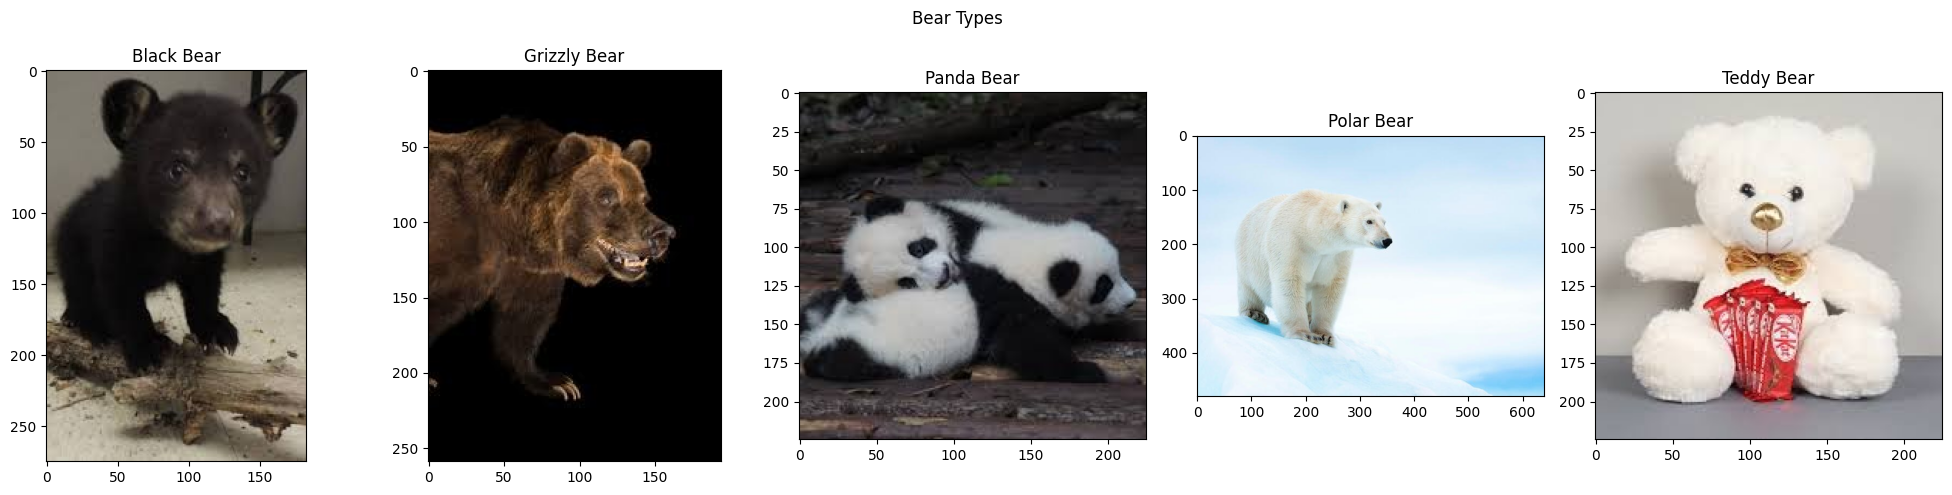

In [83]:

fig, ax = plt.subplots(ncols=5, figsize=(20,5))
fig.suptitle("Bear Types")

black_image   = img.imread(str(black[0]))
grizzly_image = img.imread(str(grizzly[0]))
panda_image   = img.imread(str(panda[0]))
polar_image   = img.imread(str(polar[0]))
teddy_image   = img.imread(str(teddy[0]))

ax[0].imshow(black_image);   ax[0].set_title("Black Bear");   ax[0].axis("on")
ax[1].imshow(grizzly_image); ax[1].set_title("Grizzly Bear"); ax[1].axis("on")
ax[2].imshow(panda_image);   ax[2].set_title("Panda Bear");   ax[2].axis("on")
ax[3].imshow(polar_image);   ax[3].set_title("Polar Bear");   ax[3].axis("on")
ax[4].imshow(teddy_image);   ax[4].set_title("Teddy Bear");   ax[4].axis("on")
plt.tight_layout()
plt.show()




Assigning a separate dictionary for images and their corresponding labels

In [84]:
#contain the image path 

df_labels = {
    'black' : black, 
    'grizzly' : grizzly,
    'panda' : panda,
    'polar' : polar,
    'teddy' : teddy
}

df_labels = {
    'black' : 0,
    'grizzly' :1,
    'panda' : 2,
    'polar' : 3,
    'teddy' : 4
}


Since the MobileNetv2 training images dimensions are 224 by 224 by 3, we have to reshape our categories into that

In [85]:

x, y = [], [] # X = images, y = labels

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

x, y = [], []  # X = images, y = labels

for label, images in df_images.items():
    for image in images:
        img_path = Path(image)

        # ✅ Skip hidden/system files like .DS_Store
        if img_path.name.startswith("."):
            continue

        # ✅ Skip non-image files
        if img_path.suffix.lower() not in IMG_EXTS:
            continue

        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None:
            print("Failed to read:", img_path)
            continue

        resized = cv2.resize(img, (224, 224))
        x.append(resized)
        y.append(df_labels[label])
        
        

Splitting data and Standarization 

In [86]:
#standarizing
x = np.array(x)
x = x/255
y = np.array(y)

# since the dataset is small enough, so we won't add validation (train =80%, test = 20%)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

# Creating model 

In [87]:
#summary of the model
#model = MobileNetV2(weights ='imagenet')
#print(model.summary())

In [88]:
#loading the model
from tensorflow.keras.models import Sequential
mobile_net = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
mobile_net.trainable = False


In [89]:
x = mobile_net.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)

model = keras.Model(inputs=mobile_net.input, outputs=predictions)
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,078,725 (11.74 MB)

 Trainable params: 820,741 (3.13 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [90]:
for layer in model.layers[:5]:
    layer.trainable = False

epochs = 10

#compiling the model

model.compile(loss ="categorical_crossentropy", optimizer = Adam(learning_rate=0.001), metrics = ['accuracy'])

# train 
model.fit(x_train, keras.utils.to_categorical(y_train, num_classes=5), epochs=epochs, batch_size=32, validation_data=(x_test, keras.utils.to_categorical(y_test, num_classes=5)))

path_for_saving = "/Users/sivhoung/Library/Mobile Documents/com~apple~CloudDocs/bear classification /bear_model/model.h5"
model.save(path_for_saving)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 0.6235 - loss: 1.0365 - val_accuracy: 0.9355 - val_loss: 0.3962
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.9636 - loss: 0.1457 - val_accuracy: 0.9677 - val_loss: 0.1796
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.9960 - loss: 0.0402 - val_accuracy: 0.9194 - val_loss: 0.3272
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.9636 - loss: 0.0772 - val_accuracy: 0.9516 - val_loss: 0.1786
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.9355 - val_loss: 0.2526
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9194 - val_loss: 0.2715
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9355 - val_loss: 0.2531
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 1.0000 - loss: 4.0890e-04 - val_accuracy: 0.9355 - val_l

# Test the model 

In [93]:
#test the model with x_test 
predictions = model.predict(x_test)

# If it's a classification model, get the class with the highest probability
predicted_class = np.argmax(predictions, axis=1)  # For classification tasks


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


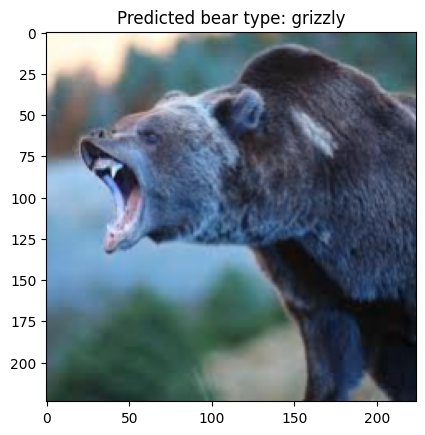

In [94]:
# Display the result
# Convert the predicted class to an integer
predicted_class_int = int(predicted_class[0])

# Now map the integer to the bear type using the dictionary
predicted_bear = list(df_labels.keys())[list(df_labels.values()).index(predicted_class_int)]

plt.imshow(x_test[0])
plt.title(f"Predicted bear type: {predicted_bear}")
plt.show()